In [1]:
!pip install ultralytics opencv-python numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable


# Pipeline Giám Sát Đám Đông

## Tổng Quan
Notebook triển khai hệ thống giám sát đám đông thời gian thực sử dụng YOLOv8 để phát hiện đối tượng, ByteTrack để theo dõi đa đối tượng, và logic tùy chỉnh để đếm và phát hiện lảng vảng trong khu vực đa giác. Hệ thống được tối ưu cho thiết bị edge và tập trung vào phát hiện người, xe đạp và ô tô.

## Cài Đặt và Import
Cài đặt các thư viện cần thiết và import các module cho thị giác máy tính, học máy và xử lý dữ liệu.

In [1]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

## Tải Mô Hình
Tải mô hình YOLOv8s, được chọn từ benchmarking trong yolo-model.ipynb để hiệu suất tối ưu trên thiết bị edge. Mô hình này phát hiện người (class 0), xe đạp (class 1) và ô tô (class 3).

In [2]:
model = YOLO("yolov8s.pt")  # Use YOLOv8s for edge devices (selected from yolo-model.ipynb benchmark)

from dataclasses import dataclass
from typing import List, Tuple
import numpy as np

@dataclass
class YoloOutput:
    frame_id: int
    boxes_xyxy: np.ndarray
    confidences: np.ndarray
    class_ids: np.ndarray
    centers: List[Tuple[float, float]]

CONF_THRESHOLD = 0.4
def detect(model, frame, frame_id):
    results = model(frame, classes=[0, 1, 3], conf=CONF_THRESHOLD, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    conf = results[0].boxes.conf.cpu().numpy()
    class_ids = results[0].boxes.cls.cpu().numpy()
    centers = []
    for box in boxes:
        x1, y1, x2, y2 = box
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        centers.append((cx, cy))
    output = YoloOutput(
        frame_id=frame_id,
        boxes_xyxy=boxes,
        confidences=conf,
        class_ids=class_ids,
        centers=centers
    )
    return output

## Tải Ảnh
Tải ảnh mẫu từ dataset Shanghai để demo pipeline. Trong hệ thống thời gian thực, phần này sẽ được thay bằng capture video từ camera.

Image loaded successfully!


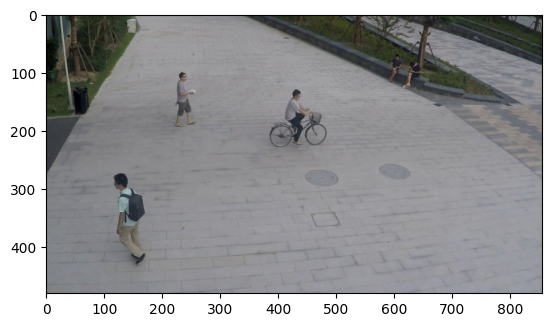

In [3]:
# Load image from Shanghai dataset
image_path = r"Shanghaidataset\shanghaitech\shanghaitech\testing\frames\01_0014\186.jpg"
frame = cv2.imread(image_path)
if frame is None:
    print("Error: Image not found!")
else:
    print("Image loaded successfully!")
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.show()

## Đa Giác và Hàm Tiện Ích
Định nghĩa đa giác giám sát (khu vực hình chữ nhật) và các hàm trợ giúp:
- `inside_polygon`: Kiểm tra điểm (trọng tâm) có nằm trong đa giác không bằng OpenCV.
- `count_in_polygon`: Đếm chỉ người (class 0) trong đa giác để đếm đám đông chính xác.
- TODO: Triển khai đếm flow để theo dõi người qua biên giới đa giác theo thời gian.

BYTETRACK

In [4]:
import numpy as np

polygon = np.array([
    (100,100),
    (500,100),
    (500,400),
    (100,400)
])

def inside_polygon(point, polygon):
    return cv2.pointPolygonTest(polygon, point, False) >= 0

def count_in_polygon(tracks, polygon):
    count = 0
    for track in tracks:
        x1, y1, x2, y2, track_id, class_id = track  # Unpack class_id
        if class_id == 0:  # Only count persons (class 0)
            cx = (x1 + x2) // 2
            cy = (y1 + y2) // 2
            if inside_polygon((cx, cy), polygon):
                count += 1
    return count
# TODO: Add flow counting - track trajectory crossing polygon boundary over time

## ByteTrack Integration
ByteTrack is a multi-object tracking algorithm that improves upon SORT by handling low-confidence detections and reducing ID switches. Here, we use the integrated ByteTrack from Ultralytics YOLO for seamless detection and tracking.

In [ ]:
import sys
import os

# %pip install loguru thop opencv-python cython_bbox
sys.path.insert(0, r"D:\Anomaly-Detection-in-Surveillance-Videos\ByteTrack")
# run in terminal: git clone https://github.com/ifzhang/ByteTrack.git
#cd Bytetrack ; pip install -r requirements.txt 
#use python 3.10
from yolox.tracker.byte_tracker import BYTETracker 

## Loitering Detection
Detect persons loitering in the polygon area. Combines time-based detection (>5 seconds) with velocity check (<0.5 pixels/frame) to avoid false positives for slow-moving persons. Uses track history to calculate average velocity.
- TODO: Enhance with motion vector analysis for more robust detection.

In [6]:

def convert_to_bytetrack(yolo_output):
    detections = []
    for i in range(len(yolo_output.boxes_xyxy)):
        x1, y1, x2, y2 = yolo_output.boxes_xyxy[i]
        conf = yolo_output.confidences[i]
        detections.append([x1, y1, x2, y2, conf])
    return np.array(detections)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
# Initialize BYTETracker
from argparse import Namespace
args = Namespace(track_thresh=0.5, track_buffer=30, match_thresh=0.8)
tracker = BYTETracker(args)

In [8]:
import time

loiter_dict = {}
THRESHOLD_TIME = 5  # seconds
VELOCITY_THRESHOLD = 0.5  # pixels per frame, adjust based on FPS

def check_loitering(tracks, polygon, loiter_dict, current_time):
    alerts = []
    for track in tracks:
        x1, y1, x2, y2, track_id, class_id = track
        cx = (x1 + x2) // 2
        cy = (y1 + y2) // 2

        if inside_polygon((cx, cy), polygon) and class_id == 0:  # Only for persons
            if track_id not in loiter_dict:
                loiter_dict[track_id] = {'start_time': current_time, 'positions': [(cx, cy)]}
            else:
                # Update positions for velocity check
                loiter_dict[track_id]['positions'].append((cx, cy))
                if len(loiter_dict[track_id]['positions']) > 5:  # Keep last 5 positions
                    loiter_dict[track_id]['positions'].pop(0)

                # Calculate velocity (average movement over last positions)
                if len(loiter_dict[track_id]['positions']) > 1:
                    displacements = [np.linalg.norm(np.array(p2) - np.array(p1)) for p1, p2 in zip(loiter_dict[track_id]['positions'][:-1], loiter_dict[track_id]['positions'][1:])]
                    avg_velocity = np.mean(displacements)
                else:
                    avg_velocity = 0

                duration = current_time - loiter_dict[track_id]['start_time']
                if duration > THRESHOLD_TIME and avg_velocity < VELOCITY_THRESHOLD:  # Time + low velocity
                    alerts.append(track_id)
        else:
            if track_id in loiter_dict:
                del loiter_dict[track_id]
    return alerts




# TODO: Enhance with motion vector analysis for better loitering detection

## Image Processing Pipeline
Process the loaded image through the full pipeline:
1. Run YOLO tracking to get detections and tracks.
2. Extract bounding boxes, track IDs, and class IDs.
3. Draw polygon overlay.
4. Count persons in polygon.
5. Check for loitering alerts.
6. Visualize results with bounding boxes, IDs, classes, and count.
7. Display processed image.

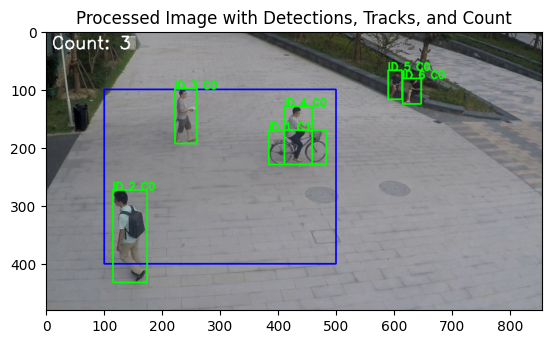

Total detections: 6
Active tracks: 6
Count in polygon (persons only): 3
Loitering alerts: []


In [9]:
import time

# Process the loaded frame
frame_id = 0
yolo_output = model.track(frame, persist=True, classes=[0, 1, 3], conf=CONF_THRESHOLD, verbose=False)

# Get tracks from ultralytics, including class_ids
tracks = []
if yolo_output[0].boxes.id is not None:
    boxes = yolo_output[0].boxes.xyxy.cpu().numpy()
    ids = yolo_output[0].boxes.id.cpu().numpy().astype(int)
    classes = yolo_output[0].boxes.cls.cpu().numpy().astype(int)  # Add class_ids
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        track_id = ids[i]
        class_id = classes[i]
        tracks.append([x1, y1, x2, y2, track_id, class_id])  # Add class_id to track

# Draw polygon for debug
cv2.polylines(frame, [polygon], True, (255,0,0), 2)

# Count only persons (class 0) in polygon
count = count_in_polygon(tracks, polygon)

# Loitering
current_time = time.time()
alerts = check_loitering(tracks, polygon, loiter_dict, current_time)

# Draw tracks with color based on loitering
for track in tracks:
    x1, y1, x2, y2, track_id, class_id = track
    color = (0,0,255) if track_id in alerts else (0,255,0)
    cv2.rectangle(frame, (int(x1),int(y1)), (int(x2),int(y2)), color, 2)
    cv2.putText(frame, f"ID {track_id} C{class_id}", (int(x1),int(y1)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Display count
cv2.putText(frame, f"Count: {count}", (10,30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

# Show processed image with matplotlib
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("Processed Image with Detections, Tracks, and Count")
plt.show()

print(f"Total detections: {len(tracks)}")
print(f"Active tracks: {len(tracks)}")
print(f"Count in polygon (persons only): {count}")
print(f"Loitering alerts: {alerts}")

## Results and Next Steps
The processed image shows detections, tracks, and counts. Key features:
- Accurate person counting (excludes non-person objects).
- Stable tracking with ByteTrack.
- Loitering alerts with velocity filtering.

For production:
- Extend to real-time video processing.
- Add anomaly detection (e.g., running/pushing).
- Integrate web UI, database, and hardware controls.
- Optimize for edge devices (quantization, TensorRT).